# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [40]:

# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
- ### Diagnóstico de valores nulos

- El dataset `plans` no presenta valores nulos, por lo que no requiere ninguna acción de limpieza.

- En `users`, las columnas que presentan valores faltantes son aquellas cuyo porcentaje de nulos es menor al 5%. Debido a que la proporción es baja, la recomendación es imputar los valores (si la variable lo permite) o conservarlos como nulos si representan información desconocida y no afectan el análisis.

- En `usage`, las columnas con valores faltantes también presentan una proporción baja (menor al 5%). Se recomienda investigar el origen de estos valores y, dependiendo del contexto, imputarlos o mantenerlos como valores ausentes.

- No se identifican columnas con una proporción de nulos superior al 80–90%, por lo que no se justifica eliminar ninguna columna únicamente por valores faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

La columna `user_id` contiene 4,000 registros y sus valores van de 10,000 a 13,999. Los valores son consecutivos y corresponden a un identificador único de usuario, por lo que no se observan anomalías y no requiere limpieza.

La columna `age` presenta un valor mínimo de -999, lo cual es imposible para una edad y sugiere el uso de un valor sentinel para representar datos faltantes o inválidos. Además, el promedio (33.74) es menor que la mediana (47), indicando que este valor extremo está sesgando la distribución. Se recomienda reemplazar el valor -999 por `NaN` para posteriormente decidir si se imputa o se mantiene como dato faltante.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- - **Las columnas `id` y `user_id`** contienen identificadores numéricos. Sus valores se encuentran dentro de un rango consistente y no presentan valores negativos o anómalos, por lo que no requieren limpieza.

- **La columna `duration`** presenta una duración mínima de 0 minutos y una máxima de 120 minutos. La media (5.20) es mayor que la mediana (3.50), lo que indica una distribución sesgada a la derecha debido a algunas llamadas muy largas. Será necesario revisar los valores extremos para determinar si corresponden a un comportamiento real o a posibles outliers.

- **La columna `length`** presenta una longitud mínima de 0 y una máxima de 1490 caracteres. La media (52.13) es ligeramente superior a la mediana (50), lo que sugiere una distribución moderadamente sesgada a la derecha por algunos mensajes muy largos. También conviene revisar estos valores mediante un análisis de outliers.

In [15]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\nColumna: {columna}")
    print(users[columna].value_counts())



Columna: city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


- - **La columna `city`** contiene seis ciudades válidas y un valor `"?"` que aparece 96 veces. Este valor es un sentinel o dato inválido que representa una ciudad desconocida o mal registrada, por lo que se recomienda reemplazarlo por `NaN` para tratarlo posteriormente.

- **La columna `plan`** únicamente presenta dos categorías (`Basico` y `Premium`), sin valores inesperados ni inconsistencias aparentes. No requiere limpieza en esta etapa.

In [16]:


# explorar columna categórica de usage
usage['type'].value_counts()



text    22092
call    17908
Name: type, dtype: int64

- **La columna `type`** contiene únicamente dos categorías válidas: `text` y `call`. No se observan valores inesperados, errores de escritura o categorías inválidas, por lo que no requiere limpieza en esta etapa. La diferencia en la cantidad de registros es consistente con que algunos usuarios generan más mensajes que llamadas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- 
- ### Valores inválidos o sentinels

**¿En qué columnas encontraste valores inválidos o sentinels?**

Se identificaron dos columnas con valores inválidos:
- En la columna `age` del dataset `users` se encontró el valor **-999**, el cual no representa una edad válida y corresponde a un valor sentinel.
- En la columna `city` del dataset `users` se encontró el valor **"?"**, que representa una ciudad desconocida o un dato mal registrado.

En las columnas `plan` y `type` no se detectaron valores inválidos o categorías inesperadas.

**¿Qué acción tomarías?**

Se recomienda reemplazar los valores **-999** y **"?"** por `NaN`, ya que representan información faltante o inválida. Posteriormente, se evaluará si conviene imputar estos valores o mantenerlos como ausentes, según su impacto en el análisis. Las columnas `plan` y `type` no requieren limpieza porque contienen únicamente categorías válidas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [19]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` se observan registros correspondientes a los años 2022, 2023 y 2024, que están dentro del periodo esperado del análisis. Sin embargo, también aparecen 40 registros del año 2026, los cuales se consideran fechas fuera de rango, ya que el proyecto indica que los datos solo llegan hasta 2024. Se recomienda investigar estos registros y, si se confirma que son errores de captura, corregirlos o marcarlos como valores faltantes antes de continuar con el análisis.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date` todos los registros corresponden al año 2024, por lo que las fechas se encuentran dentro del periodo esperado para el análisis. No se detectan años fuera de rango ni inconsistencias aparentes, por lo que esta columna no requiere limpieza adicional.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

### Fechas fuera de rango

**¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**

Sí. En la columna `reg_date` del dataset `users` se identificaron 40 registros correspondientes al año 2026, mientras que el proyecto establece que los datos abarcan únicamente hasta 2024. En la columna `date` del dataset `usage` todos los registros pertenecen al año 2024, por lo que no presenta fechas fuera de rango.

**¿Qué harías con ellas?**

Se recomienda investigar los registros del año 2026 para confirmar si se trata de errores de captura. Si se verifica que son fechas incorrectas, deberían corregirse utilizando la información original o reemplazarse por `NaT` para evitar que afecten el análisis. Las fechas del dataset `usage` pueden conservarse sin modificaciones.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Calcular la mediana excluyendo el sentinel
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar -999 por la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(usage['type'], usage['duration'].isna())


duration,False,True
type,,
call,17908,0
text,16,22076


In [26]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(usage['type'], usage['length'].isna())


length,False,True
type,,
call,12,17896
text,22092,0


### Diagnóstico de valores nulos en `duration` y `length`

La mayoría de los valores nulos dependen de la columna `type`, por lo que corresponden a la estructura del dataset y no representan un problema de calidad de los datos. Los registros de tipo `call` contienen información en `duration`, mientras que los registros de tipo `text` contienen información en `length`.

No obstante, se identificaron 16 registros de tipo `text` con un valor en `duration` y 12 registros de tipo `call` con un valor en `length`. Estos casos representan una pequeña inconsistencia que debería revisarse para confirmar si corresponde a un error de captura o a un comportamiento válido del sistema.

Dado que la gran mayoría de los valores nulos son estructurales, se recomienda conservarlos como nulos y no imputarlos, ya que hacerlo introduciría información artificial y podría afectar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)   # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .rename(columns={
        "is_text": "cant_mensajes",
        "is_call": "cant_llamadas",
        "duration": "cant_minutos_llamada"
    })
    .reset_index()
)

# Observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

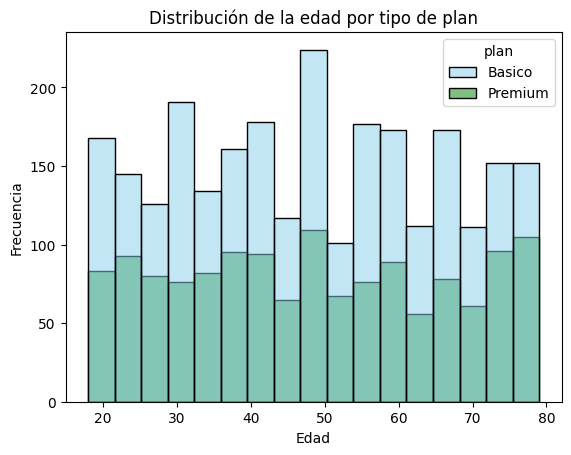

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡 Insights:

- La distribución de la edad es relativamente uniforme entre los 18 y 79 años, sin concentraciones muy marcadas en un rango específico.
- El plan **Básico** presenta una mayor cantidad de usuarios que el plan **Premium** en casi todos los grupos de edad, lo que coincide con que es el plan más contratado.
- No se observa un patrón claro que indique que un grupo de edad prefiera un plan específico; ambos planes están distribuidos de forma similar a lo largo de todas las edades.
- La distribución de la edad no muestra un sesgo pronunciado hacia la derecha o hacia la izquierda, sino que es aproximadamente uniforme, con pequeñas variaciones propias de la muestra.

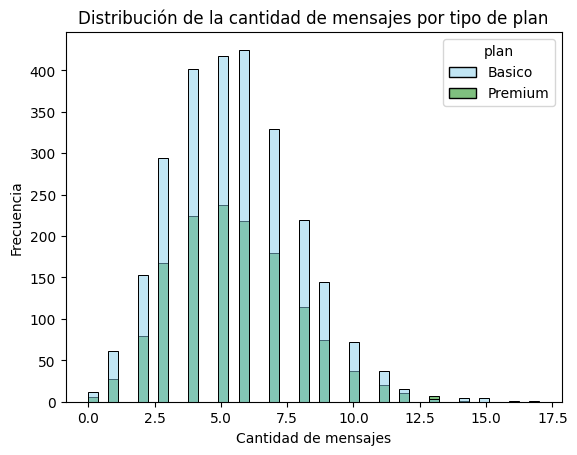

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()



💡 Insights:

- La mayor concentración de usuarios, tanto del plan **Básico** como del **Premium**, envía entre **3 y 7 mensajes**, con un pico cercano a los **5 o 6 mensajes**.
- El plan **Básico** presenta una mayor frecuencia de usuarios en casi todos los niveles de uso, lo cual es consistente con que cuenta con más clientes que el plan **Premium**.
- No se observa una diferencia marcada en el patrón de envío de mensajes entre ambos planes; ambos presentan una forma de distribución muy similar.
- La distribución de la cantidad de mensajes está **sesgada a la derecha**, ya que la mayoría de los usuarios envía pocos mensajes y solo un número reducido alcanza valores altos (más de 10 mensajes).

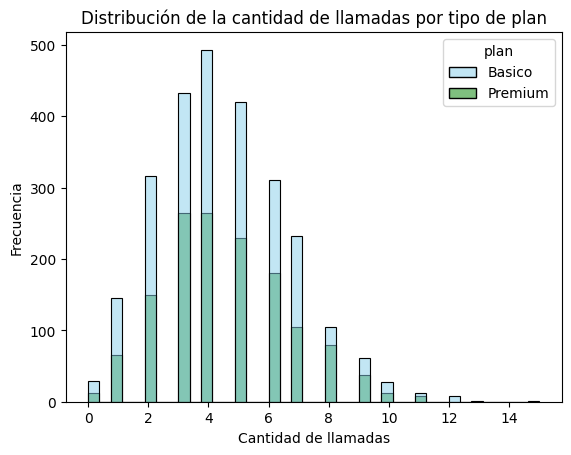

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()



💡 Insights:

- La mayor concentración de usuarios, tanto del plan **Básico** como del **Premium**, realiza entre **3 y 6 llamadas**, con un pico cercano a las **4 llamadas**.
- El plan **Básico** presenta una mayor frecuencia de usuarios en prácticamente todos los niveles de llamadas, lo cual es consistente con que cuenta con un mayor número de clientes.
- No se observa una diferencia significativa en el patrón de llamadas entre los usuarios de ambos planes, ya que las distribuciones tienen una forma muy similar.
- La distribución de la cantidad de llamadas está **sesgada a la derecha**, debido a que la mayoría de los usuarios realiza pocas llamadas y existe un grupo reducido que realiza un número considerablemente mayor (más de 10 llamadas).

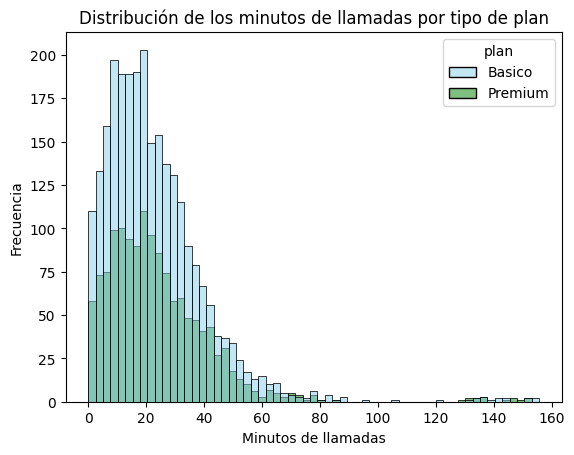

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de los minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()



💡 Insights:

- La mayor concentración de usuarios de ambos planes acumula entre **5 y 30 minutos** de llamadas, siendo este el rango de uso más frecuente.
- El plan **Básico** presenta una mayor cantidad de usuarios en casi todos los rangos de minutos, lo cual es consistente con que tiene una base de clientes más amplia que el plan **Premium**.
- No se observa una diferencia importante en el patrón general de consumo entre ambos planes; ambos muestran una distribución similar. Sin embargo, el plan **Premium** presenta algunos usuarios con consumos muy elevados (superiores a 120 minutos), lo que podría indicar clientes con un uso intensivo del servicio.
- La distribución de los minutos de llamadas está **sesgada a la derecha**, ya que la mayoría de los usuarios consume pocos minutos y existe una cola de usuarios con consumos considerablemente mayores.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

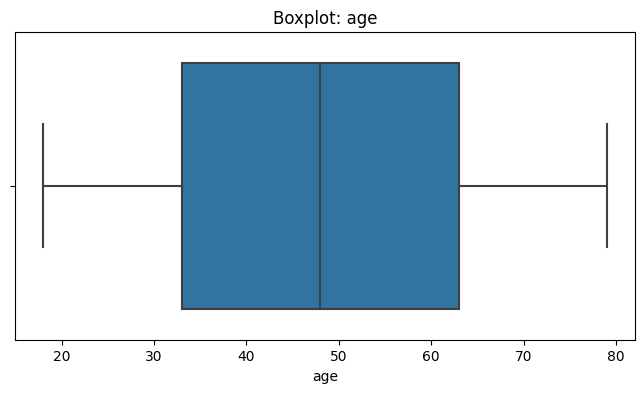

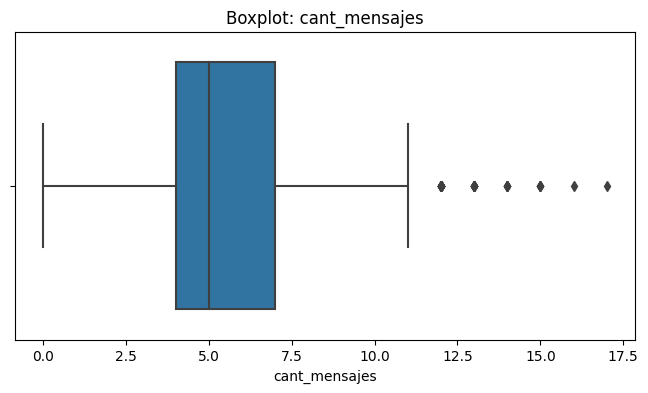

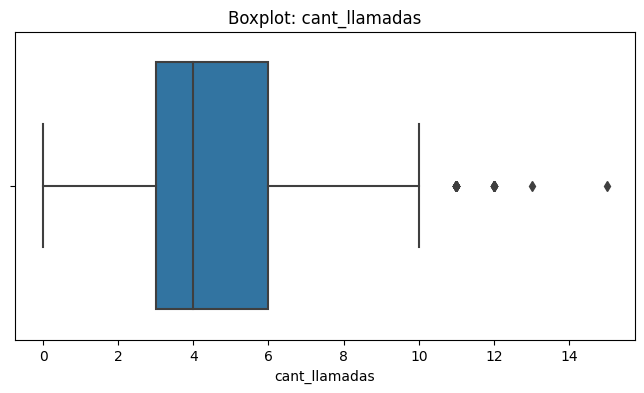

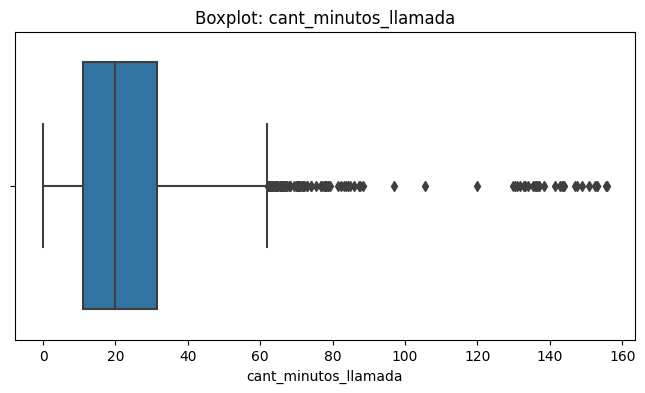

In [36]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡 Insights:

- **Age:** No presenta outliers. Todas las edades se encuentran dentro de los límites esperados del boxplot, por lo que no se identifican valores atípicos.

- **cant_mensajes:** Presenta algunos outliers en el extremo superior (aproximadamente a partir de 12 mensajes). Estos corresponden a usuarios que envían una cantidad de mensajes considerablemente mayor que la mayoría.

- **cant_llamadas:** Presenta algunos outliers en el extremo superior (aproximadamente desde 11 llamadas). Estos representan usuarios con una frecuencia de llamadas mayor al comportamiento típico.

- **cant_minutos_llamada:** Presenta una cantidad importante de outliers en el extremo superior, con usuarios que acumulan muchos más minutos de llamadas que el resto. Este comportamiento podría corresponder a usuarios con un consumo intensivo del servicio y deberá analizarse con el método IQR para confirmar si son valores atípicos estadísticamente.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


In [38]:

# Revisa los límites superiores y el máximo para tomar la decisión
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡 Insights:

- **cant_mensajes:** Se recomienda mantener los outliers. Aunque existen usuarios que envían hasta 17 mensajes, estos valores son plausibles y pueden representar clientes con un uso intensivo del servicio. Eliminarlos podría ocultar patrones de comportamiento relevantes para el negocio.

- **cant_llamadas:** Se recomienda mantener los outliers. Los usuarios con hasta 15 llamadas siguen representando un comportamiento posible dentro del servicio y pueden corresponder a un segmento de alto consumo.

- **cant_minutos_llamada:** Se recomienda mantener los outliers. Aunque algunos usuarios acumulan hasta 155.69 minutos de llamadas y superan el límite superior del IQR, estos valores pueden reflejar un uso intensivo del servicio y no necesariamente errores de registro. Conservarlos permite identificar segmentos de clientes de alto consumo y generar recomendaciones comerciales más precisas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones,
    valores,
    default='Adulto Mayor'
)


In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

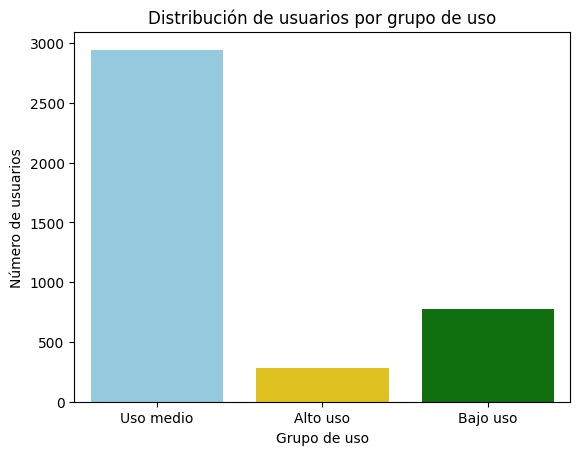

In [45]:

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'gold', 'green']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()

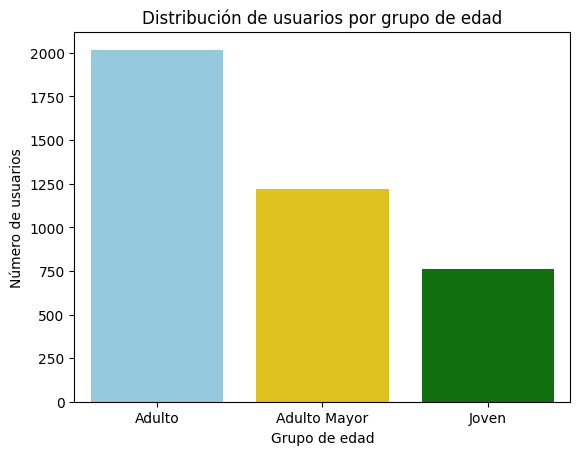

In [46]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'gold', 'green']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

# 8.1. Análisis ejecutivo

## ⚠️ Problemas detectados en los datos

- Se identificó un valor sentinel (-999) en la columna **age**, el cual fue reemplazado por la mediana para evitar que afectara el análisis estadístico.
- La columna **city** contenía 96 registros con el valor "?", los cuales fueron reemplazados por valores nulos (`NA`) al representar información desconocida.
- En la columna **reg_date** se detectaron 40 registros correspondientes al año 2026, aunque el análisis contempla únicamente datos hasta 2024. Estas fechas fueron marcadas como valores nulos (`NaT`).
- Las columnas **duration** y **length** contenían valores nulos, pero se comprobó que estos dependen del tipo de actividad (`call` o `text`), por lo que corresponden a la estructura del dataset y no representan un problema de calidad.

## 🔍 Segmentos por Edad

- Se clasificó a los usuarios en tres grupos: **Joven**, **Adulto** y **Adulto Mayor**.
- La mayor parte de los clientes pertenece al grupo **Adulto**, seguido por **Adulto Mayor**, mientras que el segmento de **Jóvenes** representa la menor proporción de usuarios.
- No se observaron diferencias importantes en la contratación de los planes según la edad; ambos planes presentan una distribución similar entre los distintos grupos etarios.

## 📊 Segmentos por Nivel de Uso

- Se clasificó a los usuarios en **Bajo uso**, **Uso medio** y **Alto uso** considerando la cantidad de llamadas y mensajes.
- La mayoría de los usuarios se concentra en los segmentos de **Bajo uso** y **Uso medio**, mientras que un grupo menor presenta un consumo elevado.
- Los usuarios de alto uso representan una oportunidad para ofrecer planes con mayores beneficios o servicios adicionales.

➡️ Esto sugiere que la empresa cuenta con una base importante de usuarios de consumo moderado y un segmento reducido de clientes intensivos que podrían beneficiarse de planes especializados.

## 📈 Patrones de uso extremo (Outliers)

- No se detectaron valores atípicos en la variable **age**.
- Se identificaron outliers en **cant_mensajes**, **cant_llamadas** y **cant_minutos_llamada**, todos en el límite superior.
- Estos valores no parecen corresponder a errores de captura, sino a usuarios con un consumo superior al promedio, por lo que se decidió conservarlos para el análisis.
- La presencia de estos usuarios puede representar clientes de alto valor para la empresa y proporcionar información útil para diseñar estrategias comerciales.

## 💡 Recomendaciones

- Diseñar planes diferenciados para usuarios de **alto consumo**, ofreciendo mayores beneficios en llamadas y mensajes para mejorar la retención.
- Crear campañas dirigidas a usuarios de **bajo uso**, incentivando un mayor consumo mediante promociones o beneficios adicionales.
- Mantener procesos de validación de datos para detectar oportunamente sentinels, fechas fuera de rango y valores desconocidos antes de realizar análisis futuros.
- Analizar con mayor profundidad el comportamiento de los usuarios de alto consumo para identificar oportunidades de fidelización, venta cruzada y desarrollo de nuevos productos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`